# Matrix Transformations & Eigenvectors

A matrix isn't just a grid of numbers -- it's a description of how to move every point in space. This notebook makes that concrete: pick a 2x2 matrix, watch what it does to a grid of points and a unit circle, then find the one or two directions that matrix leaves unchanged (its eigenvectors).

## The math

A matrix $A$ acts on a point $x$ by matrix-vector multiplication:

$$x' = Ax$$

Three basic building blocks:

- **Rotation** by angle $\theta$: $\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$
- **Scale** by $(s_x, s_y)$: $\begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}$
- **Shear** by $(k_x, k_y)$: $\begin{bmatrix} 1 & k_x \\ k_y & 1 \end{bmatrix}$

An **eigenvector** $v$ of $A$ is a direction that $A$ only stretches, never rotates:

$$Av = \lambda v$$

for some scalar $\lambda$ (the eigenvalue). Every other direction gets rotated by $A$; eigenvectors don't.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from linalg_playground.transforms import (
    build_rotation, build_scale, build_shear, apply_transform, eigen_directions,
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
def unit_circle_points(n=200):
    angles = np.linspace(0, 2 * np.pi, n)
    return np.column_stack([np.cos(angles), np.sin(angles)])


def grid_points(lim=2.0, step=0.5):
    xs = np.arange(-lim, lim + step, step)
    ys = np.arange(-lim, lim + step, step)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()])


def plot_before_after(A, title=""):
    circle = unit_circle_points()
    grid = grid_points()
    before = np.vstack([grid, circle])
    after = apply_transform(before, A)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    for ax, pts, label in zip(axes, [before, after], ["Before", "After"]):
        ax.scatter(pts[:, 0], pts[:, 1], s=6, color="tab:blue")
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(label)
    fig.suptitle(title)
    plt.show()
    return fig

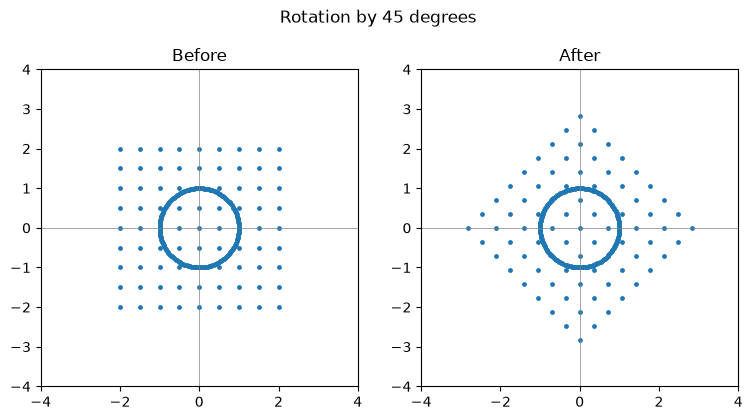

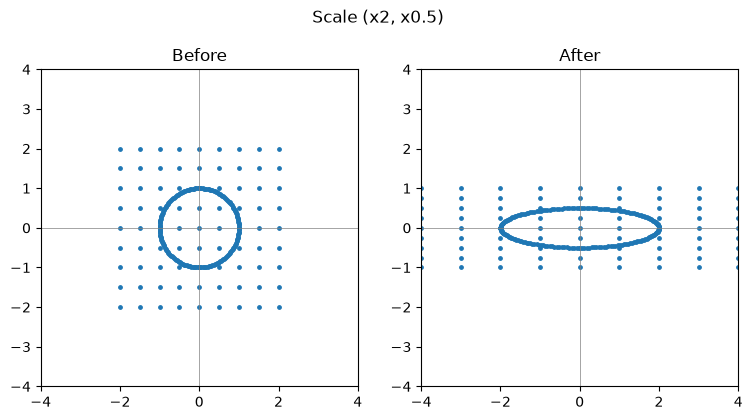

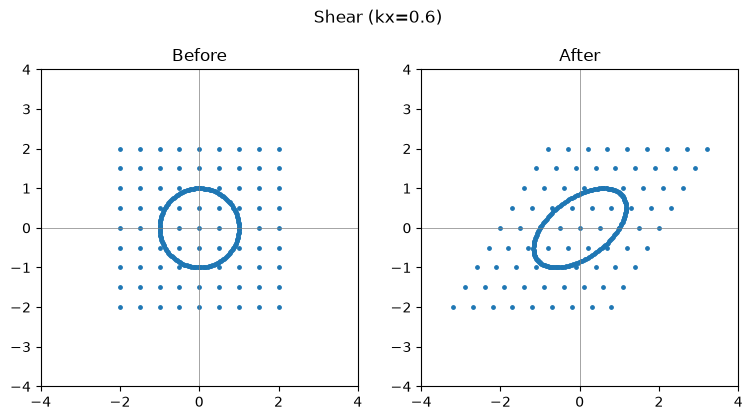

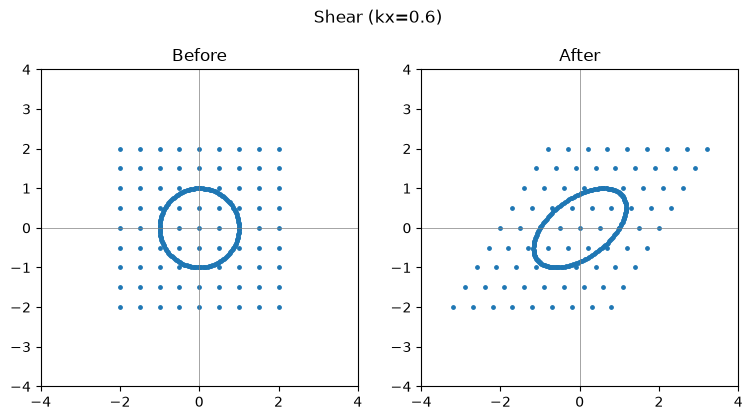

In [3]:
plot_before_after(build_rotation(np.pi / 4), "Rotation by 45 degrees")
plot_before_after(build_scale(2.0, 0.5), "Scale (x2, x0.5)")
plot_before_after(build_shear(0.6, 0.0), "Shear (kx=0.6)")

## Where do eigenvectors point?

Below, the gray dots trace the unit circle after being transformed by $A$; the colored arrows are the eigenvector directions, scaled by their eigenvalues. Watch how every other direction on the circle bends, but the arrows keep pointing the same way (only their length changes).

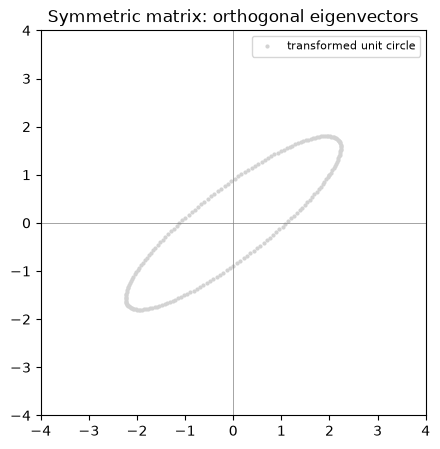

eigenvalues: [2.78077641+0.j 0.71922359+0.j]


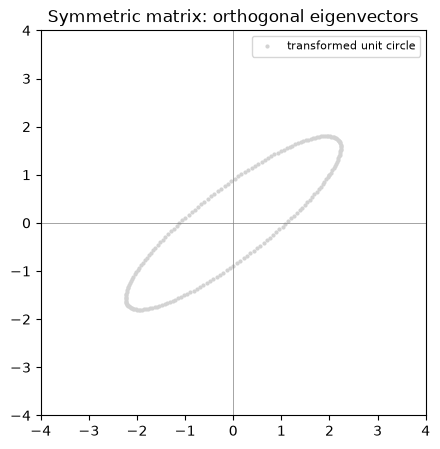

In [4]:
def plot_eigen_directions(A, title=""):
    eigvals, eigvecs = eigen_directions(A)
    circle = unit_circle_points()
    transformed = apply_transform(circle, A)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(transformed[:, 0], transformed[:, 1], s=4, color="lightgray", label="transformed unit circle")

    if not np.iscomplexobj(eigvecs):
        for i in range(eigvecs.shape[1]):
            v = eigvecs[:, i]
            scale = eigvals[i]
            ax.arrow(0, 0, v[0] * scale, v[1] * scale, head_width=0.1,
                      length_includes_head=True, color=f"C{i}", label=f"eigenvector {i} (lambda={eigvals[i]:.2f})")
            ax.arrow(0, 0, -v[0] * scale, -v[1] * scale, head_width=0.1,
                      length_includes_head=True, color=f"C{i}")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title)
    plt.show()
    print("eigenvalues:", eigvals)
    return fig


symmetric_A = np.array([[2.0, 1.0], [1.0, 1.5]])
plot_eigen_directions(symmetric_A, "Symmetric matrix: orthogonal eigenvectors")

## What about a pure rotation?

A rotation matrix (other than 0 degrees or 180 degrees) has no *real* eigenvector -- every direction actually turns. NumPy will report complex eigenvalues in that case, which is itself a useful signal: complex eigenvalues mean "this transform rotates, it doesn't just stretch along fixed axes.\"

In [5]:
rotation_eigvals, _ = eigen_directions(build_rotation(np.pi / 3))
print("Rotation eigenvalues (complex - no real eigenvector):", rotation_eigvals)

Rotation eigenvalues (complex - no real eigenvector): [0.5+0.8660254j 0.5-0.8660254j]


## Try it yourself

The cell below gives you sliders for the four entries of $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$. Drag them and watch the grid, the transformed unit circle, and the eigenvector arrows update live.

**Note:** the sliders only respond when this notebook is run locally (`uv run jupyter lab`) -- GitHub's notebook preview renders the last-saved static output only. The static plots above already show the same idea for a few representative matrices.

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0), FloatSlider(value=0.0, descr…

<function __main__.update(a=1.0, b=0.0, c=0.0, d=1.0)>

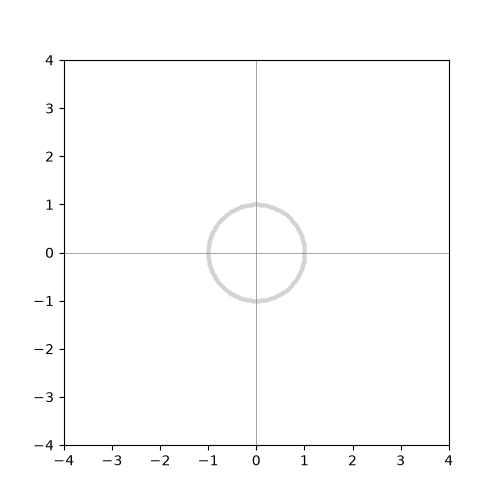

In [6]:
%matplotlib widget
import ipywidgets as widgets

fig, ax = plt.subplots(figsize=(5, 5))


def update(a=1.0, b=0.0, c=0.0, d=1.0):
    ax.clear()
    A = np.array([[a, b], [c, d]])
    circle = unit_circle_points()
    transformed = apply_transform(circle, A)
    ax.scatter(transformed[:, 0], transformed[:, 1], s=4, color="lightgray")

    eigvals, eigvecs = eigen_directions(A)
    if not np.iscomplexobj(eigvecs):
        for i in range(eigvecs.shape[1]):
            v = eigvecs[:, i]
            scale = eigvals[i]
            ax.arrow(0, 0, v[0] * scale, v[1] * scale, head_width=0.1,
                      length_includes_head=True, color=f"C{i}")
            ax.arrow(0, 0, -v[0] * scale, -v[1] * scale, head_width=0.1,
                      length_includes_head=True, color=f"C{i}")

    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    fig.canvas.draw_idle()


widgets.interact(
    update,
    a=widgets.FloatSlider(min=-3, max=3, step=0.1, value=1.0),
    b=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0.0),
    c=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0.0),
    d=widgets.FloatSlider(min=-3, max=3, step=0.1, value=1.0),
)